# Figure 5 — Scoring Weight Comparison

Shows how the **embedding weight vs histogram weight** changes recommendations:

| Setting | What it optimises |
|---|---|
| `embed=1.0, colour=0.0` | **Style / shape** similarity only (embeddings) |
| `embed=0.5, colour=0.5` | **Style + colour** compatibility (embeddings + Bhattacharyya histogram) |

The same anchor item and candidate pool are used for both rows.
Figures are generated for **both rooms**.
Saved to `data/thesis_figures/comparison/fig5_weights__*.png` at 300 DPI.

In [4]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

BASE_DIR = next(
    p for p in [Path().cwd()] + list(Path().cwd().parents)
    if (p / "src" / "retrieval" / "retrieval_logic.py").exists()
)
sys.path.insert(0, str(BASE_DIR / "src" / "retrieval"))
from retrieval_logic import FurnitureRetriever, CATEGORY_CHAINS

OUT_DIR = BASE_DIR / "data" / "thesis_figures" / "comparison"
OUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.family":       "DejaVu Serif",
    "font.size":         9,
    "axes.titlesize":    10,
    "axes.titleweight":  "bold",
    "axes.labelsize":    8,
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
    "savefig.facecolor": "white",
})

# Two weight settings
WEIGHT_CONFIGS = [
    # (embed_w, hist_w, label, bg, fg, line)
    (1.0, 0.0, "Style only",      "#E3F2FD", "#0D47A1", "#1565C0"),
    (0.5, 0.5, "Style + Color",  "#E8F5E9", "#1B5E20", "#2E7D32"),
]

STEP_LABELS = {
    "bed": "Bed", "sofa": "Sofa",
    "small_storage": "Storage", "large_storage": "Storage",
    "table": "Table", "chair_stool": "Chair / Stool", "curtain": "Curtain",
}
ROOM_LABELS = {"bedrooms": "Bedrooms", "living_rooms": "Living Rooms"}

def cat_label(cat): return STEP_LABELS.get(cat, cat)
def safe_name(cat): return cat_label(cat).replace(" / ", "_").replace("/", "_").replace(" ", "_")
def open_img(path): return Image.open(path).convert("RGB")

print(f"BASE_DIR : {BASE_DIR}")
print(f"Output   : {OUT_DIR}")

BASE_DIR : d:\Programing\thesis_v2_v3
Output   : d:\Programing\thesis_v2_v3\data\thesis_figures\comparison


In [5]:
def make_weight_comparison_figure(
    room: str,
    anchor_cat: str,
    target_cat: str,
    seed: int = 0,
    n: int = 3,
) -> plt.Figure:
    """
    Figure 5: same anchor, same candidate pool, two different scoring weight settings.

    Layout (no header row; row labels sit above each results row):
      [ Query item  ] [ "Style only"   banner spanning result columns ]
      [ (spans both ] [ top-1 | top-2 | top-3 ]
      [  rows)      ] [ "Style + Color" banner spanning result columns ]
      [             ] [ top-1 | top-2 | top-3 ]
    """
    retriever = FurnitureRetriever(room=room, embed_weight=1.0, hist_weight=0.0)
    anchor    = retriever.get_random(anchor_cat, n=1)[0]

    anchor_lbl = cat_label(anchor_cat)
    target_lbl = cat_label(target_cat)
    room_lbl   = ROOM_LABELS[room]

    N_ROWS   = len(WEIGHT_CONFIGS)
    ANCHOR_W = 1.8
    CELL     = 1.7
    BANNER_H = 0.32

    fig_w = ANCHOR_W + n * CELL
    fig_h = N_ROWS * (CELL + BANNER_H) + 0.55

    fig = plt.figure(figsize=(fig_w, fig_h))
    gs  = gridspec.GridSpec(
        2 * N_ROWS, n + 1,
        figure=fig,
        width_ratios=[ANCHOR_W / CELL] + [1.0] * n,
        height_ratios=[BANNER_H, 1.0] * N_ROWS,
        hspace=0.08, wspace=0.06,
        top=0.90, bottom=0.04, left=0.02, right=0.99,
    )

    fig.suptitle(
        f"Scoring Weight Comparison — {room_lbl}: {anchor_lbl} → {target_lbl}",
        fontsize=10, fontweight="bold", y=0.97,
    )

    # Anchor image spans every row (banners + image rows)
    ax_a = fig.add_subplot(gs[:, 0])
    ax_a.imshow(open_img(anchor["image_path"]))
    ax_a.set_title("Query Item", fontsize=8.5, fontweight="bold",
                   color="#424242", pad=4)
    ax_a.set_xticks([]); ax_a.set_yticks([])
    for sp in ax_a.spines.values():
        sp.set_visible(True); sp.set_linewidth(1.2); sp.set_edgecolor("#9E9E9E")

    # Two (banner, row) pairs
    for row_i, (embed_w, hist_w, short_lbl, bg, fg, line) in enumerate(WEIGHT_CONFIGS):
        retriever.embed_weight = embed_w
        retriever.hist_weight  = hist_w
        items = retriever.get_compatible([anchor], target_cat, top_k=n)

        # Banner spanning all result columns
        ax_banner = fig.add_subplot(gs[2 * row_i, 1:])
        ax_banner.set_facecolor(bg)
        ax_banner.text(
            0.5, 0.5,
            f"{short_lbl}   (embed={embed_w:.1f}, color={hist_w:.1f})",
            ha="center", va="center",
            fontsize=9, fontweight="bold", color=fg,
            transform=ax_banner.transAxes,
        )
        ax_banner.set_xticks([]); ax_banner.set_yticks([])
        for sp in ax_banner.spines.values():
            sp.set_visible(True); sp.set_linewidth(0.8); sp.set_edgecolor(line)

        # Result images
        for c, item in enumerate(items[:n]):
            ax = fig.add_subplot(gs[2 * row_i + 1, c + 1])
            ax.imshow(open_img(item["image_path"]))
            ax.axis("off")
            for sp in ax.spines.values():
                sp.set_visible(True); sp.set_linewidth(0.9); sp.set_edgecolor(line)
            score = item.get("score", 0.0)
            if score != 0.0:
                ax.text(
                    0.5, 0.04, f"{score:.3f}",
                    ha="center", va="bottom", fontsize=7,
                    color=fg, fontweight="bold",
                    transform=ax.transAxes,
                    bbox=dict(boxstyle="round,pad=0.2",
                              facecolor="white", edgecolor="none", alpha=0.9),
                )

    return fig


print("Figure 5 builder ready.")

Figure 5 builder ready.



Bedrooms: Bed → Storage
Loading histogram cache...
FurnitureRetriever ready — 2662 items, 6 categories
  bed            : 553 items
  chair_stool    : 357 items
  curtain        : 431 items
  large_storage  : 368 items
  small_storage  : 636 items
  table          : 317 items


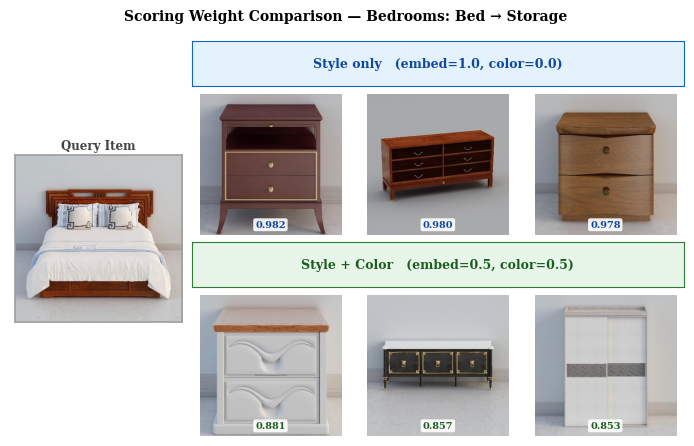

  Saved: fig5_weights__bedrooms__Bed__to__Storage.png

Bedrooms: Bed → Table
Loading histogram cache...
FurnitureRetriever ready — 2662 items, 6 categories
  bed            : 553 items
  chair_stool    : 357 items
  curtain        : 431 items
  large_storage  : 368 items
  small_storage  : 636 items
  table          : 317 items


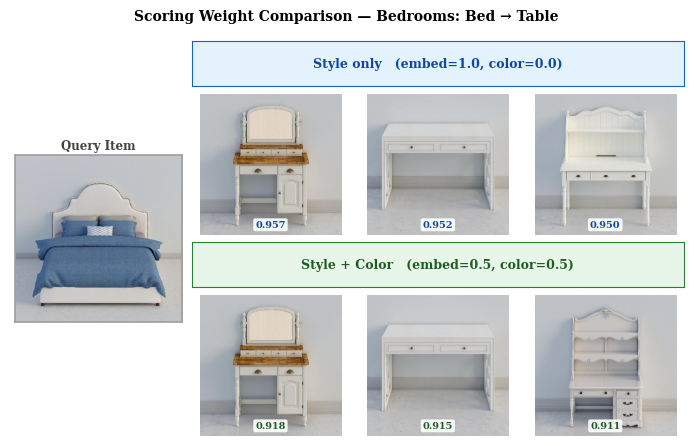

  Saved: fig5_weights__bedrooms__Bed__to__Table.png

Bedrooms: Table → Chair / Stool
Loading histogram cache...
FurnitureRetriever ready — 2662 items, 6 categories
  bed            : 553 items
  chair_stool    : 357 items
  curtain        : 431 items
  large_storage  : 368 items
  small_storage  : 636 items
  table          : 317 items


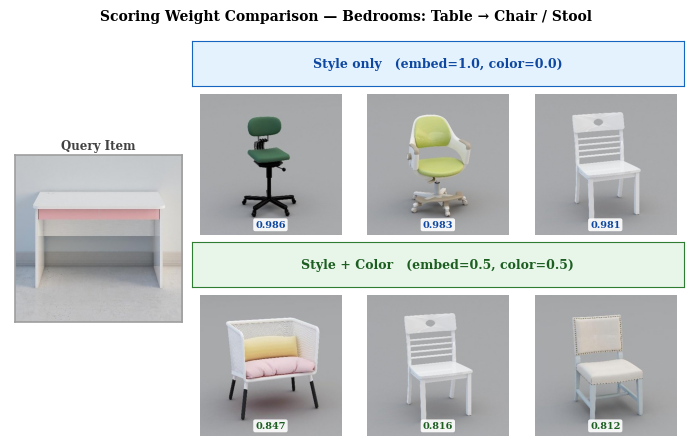

  Saved: fig5_weights__bedrooms__Table__to__Chair_Stool.png

Living Rooms: Sofa → Table
Loading histogram cache...
FurnitureRetriever ready — 2509 items, 6 categories
  chair_stool    : 220 items
  curtain        : 222 items
  large_storage  : 294 items
  small_storage  : 324 items
  sofa           : 822 items
  table          : 627 items


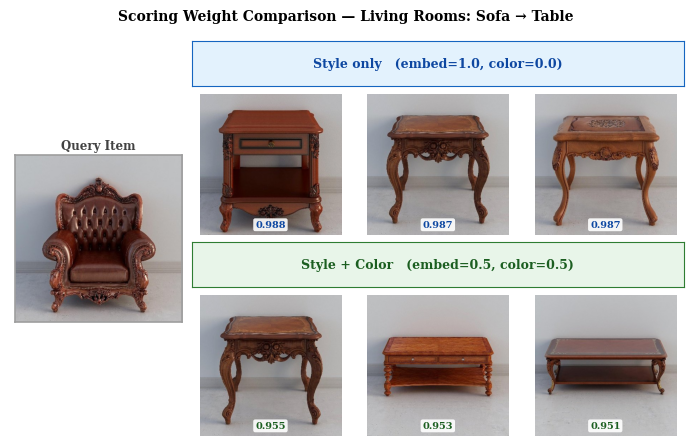

  Saved: fig5_weights__living_rooms__Sofa__to__Table.png

Living Rooms: Table → Storage
Loading histogram cache...
FurnitureRetriever ready — 2509 items, 6 categories
  chair_stool    : 220 items
  curtain        : 222 items
  large_storage  : 294 items
  small_storage  : 324 items
  sofa           : 822 items
  table          : 627 items


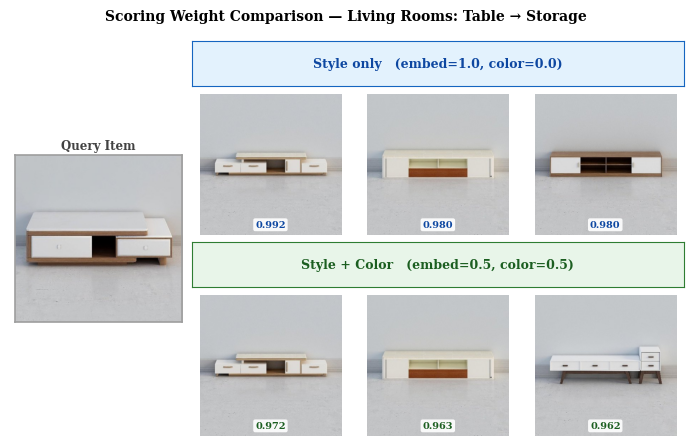

  Saved: fig5_weights__living_rooms__Table__to__Storage.png

Living Rooms: Table → Chair / Stool
Loading histogram cache...
FurnitureRetriever ready — 2509 items, 6 categories
  chair_stool    : 220 items
  curtain        : 222 items
  large_storage  : 294 items
  small_storage  : 324 items
  sofa           : 822 items
  table          : 627 items


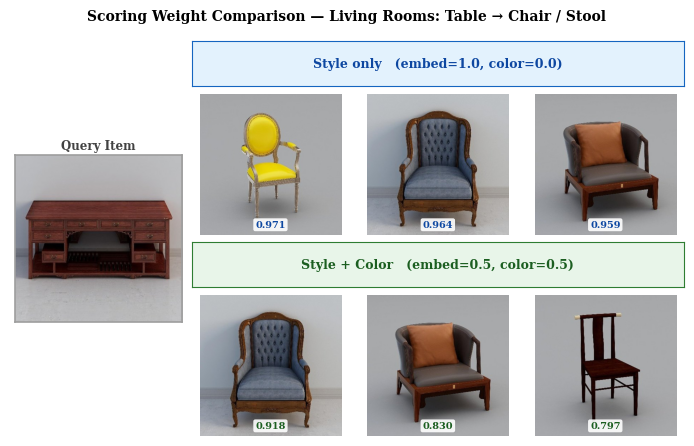

  Saved: fig5_weights__living_rooms__Table__to__Chair_Stool.png

✓ All weight comparison figures saved to: d:\Programing\thesis_v2_v3\data\thesis_figures\comparison


In [6]:
# (room, anchor_idx, target_idx, seed)
# Multiple pairs per room show different furniture types
SCENARIOS = [
    ("bedrooms",     0, 1, 0),   # Bed \u2192 Storage
    ("bedrooms",     0, 3, 0),   # Bed \u2192 Table
    ("bedrooms",     3, 4, 0),   # Table \u2192 Chair / Stool
    ("living_rooms", 0, 1, 0),   # Sofa \u2192 Table
    ("living_rooms", 1, 2, 0),   # Table \u2192 Storage
    ("living_rooms", 1, 4, 0),   # Table \u2192 Chair / Stool
]

_chains: dict = {}

for room, anc_idx, tgt_idx, seed in SCENARIOS:
    if room not in _chains:
        _chains[room] = CATEGORY_CHAINS[room]
    chain      = _chains[room]
    anchor_cat = chain[anc_idx]
    target_cat = chain[tgt_idx]
    stem       = f"{room}__{safe_name(anchor_cat)}__to__{safe_name(target_cat)}"

    print(f"\n{ROOM_LABELS[room]}: {cat_label(anchor_cat)} \u2192 {cat_label(target_cat)}")
    fig = make_weight_comparison_figure(room, anchor_cat, target_cat, seed=seed)
    p   = OUT_DIR / f"fig5_weights__{stem}.png"
    fig.savefig(p)
    plt.show()
    plt.close(fig)
    print(f"  Saved: {p.name}")

print(f"\n\u2713 All weight comparison figures saved to: {OUT_DIR}")